## 1. Data cleaning and pre-processing

In [1]:
import pandas as pd

cargoterminal_el_demand = pd.read_excel("inputs/cargoterminal_el_demand.xlsx")

In [2]:
# Take first two columns, exclude first data row after header,
# rename columns, and parse datetime
cargoterminal_el_demand = (
    cargoterminal_el_demand.iloc[1:, [0, 1]]
      .copy()
      .rename(columns={cargoterminal_el_demand.columns[0]: "datetime", cargoterminal_el_demand.columns[1]: "ampere"})
)
cargoterminal_el_demand["datetime"] = pd.to_datetime(
    cargoterminal_el_demand["datetime"], errors="coerce"
)
cargoterminal_el_demand["ampere"] = pd.to_numeric(
    cargoterminal_el_demand["ampere"], errors="coerce"
)

In [3]:
cargoterminal_el_demand.head()

,datetime,ampere
1,2025-03-01 00:15:00,13.0
2,2025-03-01 00:30:00,12.0
3,2025-03-01 00:45:00,12.0
4,2025-03-01 01:00:00,13.0
5,2025-03-01 01:15:00,12.0


In [4]:
cargoterminal_el_demand.tail()

,datetime,ampere
35035,2026-02-28 22:45:00,14.0
35036,2026-02-28 23:00:00,14.0
35037,2026-02-28 23:15:00,14.0
35038,2026-02-28 23:30:00,14.0
35039,2026-02-28 23:45:00,14.0


Since the given dataset is from March 2025 to February 2026, the January and February 2026 data is taken and shifted at the beginning of the dataset as it was 2025.

In [5]:
# Build a Jan-Dec 2025 series by moving Jan/Feb 2026 to Jan/Feb 2025
df_months_shift = cargoterminal_el_demand.copy()

mask_jan_feb_2026 = (
    (df_months_shift["datetime"].dt.year == 2026) &
    (df_months_shift["datetime"].dt.month.isin([1, 2]))
)

# Jan/Feb 2026 -> Jan/Feb 2025
part_jf_2025 = df_months_shift.loc[mask_jan_feb_2026].copy()
part_jf_2025["datetime"] = part_jf_2025["datetime"] - pd.DateOffset(years=1)

# Keep Mar-Dec 2025
part_mar_dec_2025 = df_months_shift.loc[
    (df_months_shift["datetime"].dt.year == 2025) &
    (df_months_shift["datetime"].dt.month >= 3)
].copy()

# Final dataset: Jan 2025 ... Dec 2025
cargoterminal_el_demand = (
    pd.concat([part_jf_2025, part_mar_dec_2025], ignore_index=True)
      .sort_values("datetime")
      .reset_index(drop=True)
)

# Optional quick checks
print(cargoterminal_el_demand["datetime"].min())
print(cargoterminal_el_demand["datetime"].max())
print(cargoterminal_el_demand["datetime"].dt.year.value_counts())

2025-01-01 00:00:00
2025-12-31 23:45:00
datetime
2025    35039
Name: count, dtype: int64


Converting to kWh for visualization

In [6]:
cargoterminal_el_demand_hourly = (
    cargoterminal_el_demand
    .dropna(subset=["datetime", "ampere"])
    .set_index("datetime")
    .sort_index()
    .resample("h")["ampere"]
    .sum()
    .mul(10) # multiply by voltage (10 kV)
    .mul(0.95) # multiply by power factor
    .mul(0.25) # convert to kWh
    .reset_index()
    .rename(columns={"ampere": "energy_kWh"})
)

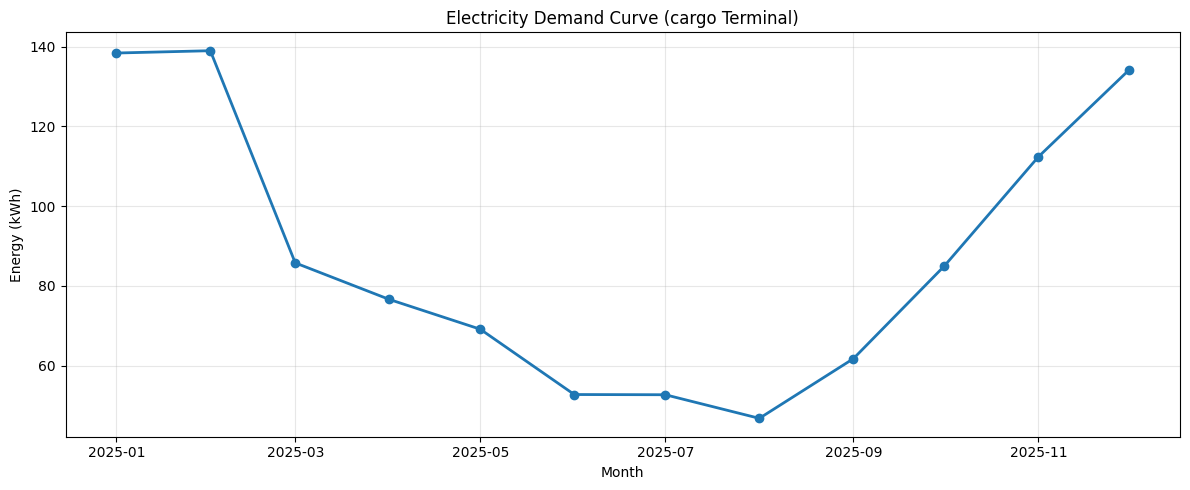

In [7]:
import matplotlib.pyplot as plt

# Ensure datetime index
df_plot = cargoterminal_el_demand_hourly.dropna(subset=["datetime", "energy_kWh"]).copy()
df_plot = df_plot.set_index("datetime").sort_index()

# Monthly demand curve (average energy per month)
monthly_curve = df_plot["energy_kWh"].resample("MS").mean()  # MS = month start

plt.figure(figsize=(12, 5))
plt.plot(monthly_curve.index, monthly_curve.values, marker="o", linewidth=2)
plt.title("Electricity Demand Curve (cargo Terminal)")
plt.xlabel("Month")
plt.ylabel("Energy (kWh)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

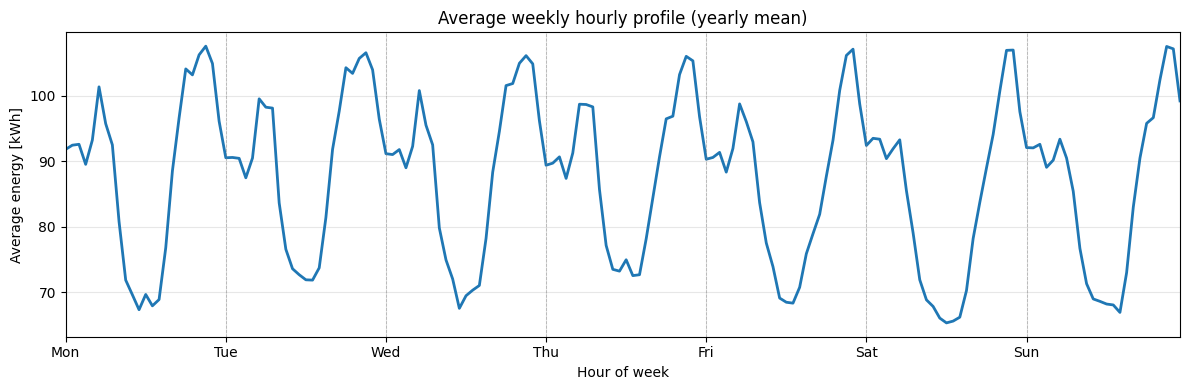

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = cargoterminal_el_demand_hourly.copy()

# 1) Ensure datetime type
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df = df.dropna(subset=["datetime"])

# 2) Build hour-of-week index: Monday 00:00 = 0, ..., Sunday 23:00 = 167
df["hour_of_week"] = df["datetime"].dt.dayofweek * 24 + df["datetime"].dt.hour

# 3) Yearly average profile per hour-of-week (168 points)
weekly_profile = (
    df.groupby("hour_of_week")["energy_kWh"]
      .mean()
      .reindex(range(168))  # keep full week order
      .reset_index(name="avg_energy_kWh")
)

# 4) Plot one-week average hourly profile
plt.figure(figsize=(12, 4))
plt.plot(weekly_profile["hour_of_week"], weekly_profile["avg_energy_kWh"], linewidth=2)

# Day separators and labels
day_starts = [0, 24, 48, 72, 96, 120, 144]
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
for x in day_starts:
    plt.axvline(x=x, color="gray", linestyle="--", linewidth=0.6, alpha=0.5)

plt.xticks(day_starts, day_labels)
plt.xlim(0, 167)
plt.xlabel("Hour of week")
plt.ylabel("Average energy [kWh]")
plt.title("Average weekly hourly profile (yearly mean)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Converting to kW

In [9]:
cargoterminal_power_demand = (
    cargoterminal_el_demand
    .dropna(subset=["datetime", "ampere"])
    .set_index("datetime")
    .sort_index()
    .mul(10) # multiply by voltage (10 kV)
    .mul(0.95) # multiply by power factor
    .reset_index()
    .rename(columns={"ampere": "power_kW"})
)

cargoterminal_power_demand.head()


,datetime,power_kW
0,2025-01-01 00:00:00,152.0
1,2025-01-01 00:15:00,152.0
2,2025-01-01 00:30:00,152.0
3,2025-01-01 00:45:00,152.0
4,2025-01-01 01:00:00,152.0


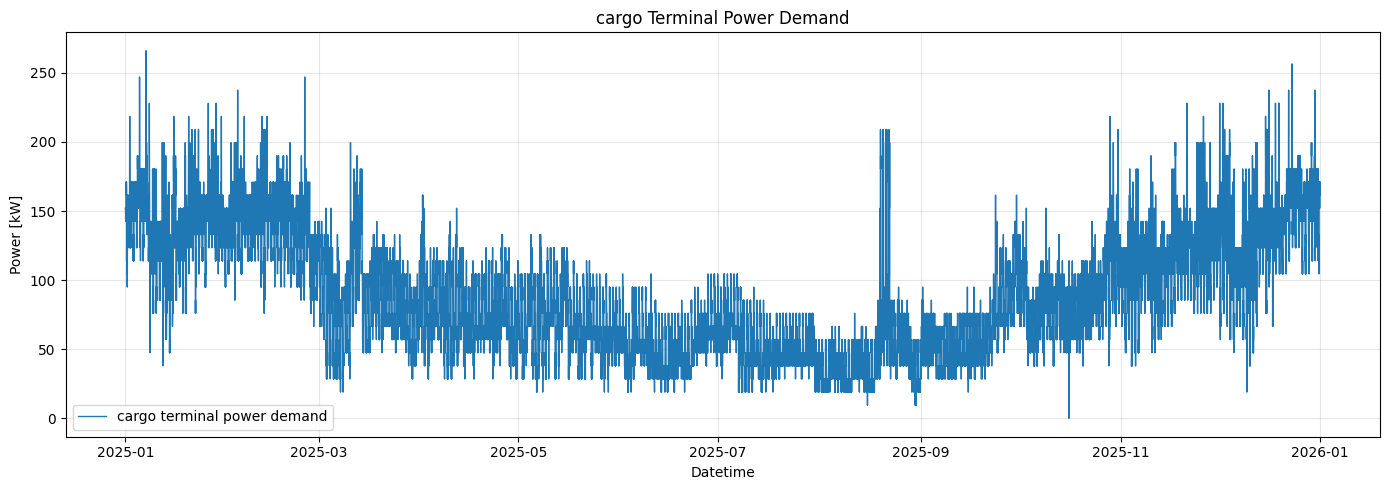

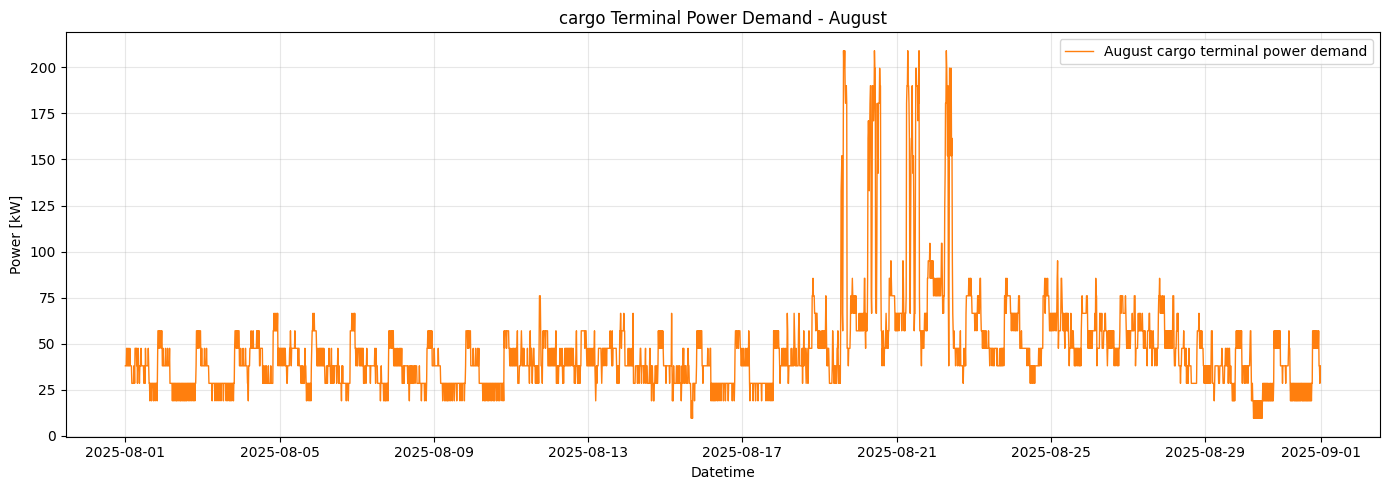

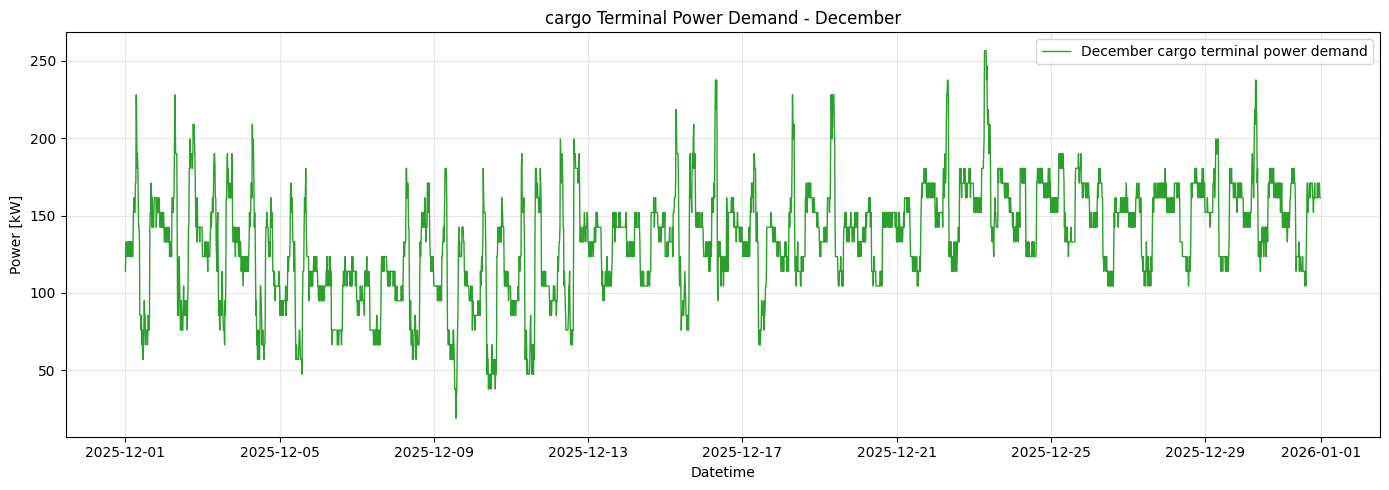

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure datetime is parsed and sorted
df_plot = cargoterminal_power_demand.copy()
df_plot["datetime"] = pd.to_datetime(df_plot["datetime"], errors="coerce")
df_plot = df_plot.dropna(subset=["datetime", "power_kW"]).sort_values("datetime")

# Full period plot
plt.figure(figsize=(14, 5))
plt.plot(df_plot["datetime"], df_plot["power_kW"], linewidth=1.0, label="cargo terminal power demand")
plt.title("cargo Terminal Power Demand")
plt.xlabel("Datetime")
plt.ylabel("Power [kW]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# August zoom-in plot
df_august = df_plot[df_plot["datetime"].dt.month == 8]

plt.figure(figsize=(14, 5))
plt.plot(df_august["datetime"], df_august["power_kW"], linewidth=1.0, color="tab:orange", label="August cargo terminal power demand")
plt.title("cargo Terminal Power Demand - August")
plt.xlabel("Datetime")
plt.ylabel("Power [kW]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# December zoom-in plot
df_december = df_plot[df_plot["datetime"].dt.month == 12]

plt.figure(figsize=(14, 5))
plt.plot(df_december["datetime"], df_december["power_kW"], linewidth=1.0, color="tab:green", label="December cargo terminal power demand")
plt.title("cargo Terminal Power Demand - December")
plt.xlabel("Datetime")
plt.ylabel("Power [kW]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 2. Optimization using Gurobi

In [11]:
port_operations = pd.read_excel("inputs/Port_Operations.xlsx")
HM_consumptions_full = pd.read_excel("inputs/HM_consumptions_15minutes.xlsx")

Reads price in EUR/MWh and converts them to SEK (1 EUR = 10.77 SEK) and EUR/kWh

In [12]:
# Read CSV from inputs and keep first + fourth columns
da_price = pd.read_excel("inputs/dayahedprices_15min.xlsx").copy()

da_price.head()

,datetime,da_price
0,2025-01-01 00:00:00,0.034111
1,2025-01-01 00:15:00,0.033426
2,2025-01-01 00:30:00,0.034068
3,2025-01-01 00:45:00,0.034528
4,2025-01-01 01:00:00,0.026369


Only taking cargo terminal related vehicles

In [13]:
import pandas as pd

# Normalize all column names in HM_consumptions
HM = HM_consumptions_full.copy()
HM.columns = (
    HM.columns.astype(str)
    .str.replace("\xa0", "", regex=False)   # remove NBSP
    .str.replace(r"\s+", " ", regex=True)   # normalize repeated spaces
    .str.strip()                            # trim edges
)

selected_cols = [
    "Truck 405", 
    "Truck 402",
    "Truck 425", 
    "Truck 426", 
    "Truck 427",
    "Truck 428", 
    "Truck 429", 
    "Truck 421", 
    "Lastmaskin 435",
    "Lastmaskin 430", 
    "Lastmaskin 439",
    "Lastmaskin 431", 
    "Lastmaskin 433", 
    "Lastmaskin 436",
    "Truck 442",
    "Truck 443",
    "Term.drag 471",
    "Term.drag 472",
    "Term.drag 475",
    "Truck 444 Krokmaskin",
]

# Keep datetime if present
keep = ["datetime"] + selected_cols

# Optional safety check
missing = [c for c in keep if c not in HM.columns]
print("Missing:", missing)

# Final filtered dataframe
HM_consumptions_cargoterminal = HM[[c for c in keep if c in HM.columns]].copy()

Missing: []


In [14]:
import numpy as np
import pandas as pd

# -----------------------------
# Assumed existing in notebook:
# - cargoterminal_power_demand: columns ["datetime", "power_kW"]
# - HM_consumptions: columns ["datetime", <vehicle IDs...>] (kWh per hour)
# - port_operations: columns ["ID", "Battery Capacity (kWh)", "Fast Charge Capacity (kW)",
#                             "Requires charging during operation"]
# -----------------------------

# --- Time set T (15-minute) built only from cargo terminal demand in kW ---
# cargoterminal_power_demand expected columns: ["datetime", "power_kW"]
base_kw = cargoterminal_power_demand[["datetime", "power_kW"]].copy()
base_kw["datetime"] = pd.to_datetime(base_kw["datetime"], errors="coerce")
base_kw["power_kW"] = pd.to_numeric(base_kw["power_kW"], errors="coerce")
base_kw = (
    base_kw
    .dropna(subset=["datetime"])
    .drop_duplicates(subset=["datetime"])
    .sort_values("datetime")
)

# Ensure an explicit 15-minute time index over the cargo-terminal demand window
full_idx = pd.date_range(
    start=base_kw["datetime"].min(),
    end=base_kw["datetime"].max(),
    freq="15min"
)

T_df = (
    pd.DataFrame({"datetime": full_idx})
    .merge(base_kw, on="datetime", how="left")
)
T_df["power_kW"] = T_df["power_kW"].fillna(0.0)

T = T_df["datetime"].to_list()

# Fixed terminal demand D[t] in kW
D_kw = T_df.set_index("datetime")["power_kW"].to_dict()

# Helpful index maps
t2i = {t: i for i, t in enumerate(T)}
i2t = {i: t for t, i in t2i.items()}

# --- Vehicle set V from port_operations (Step 24=C) ---
po = port_operations.copy()
po["ID"] = po["ID"].astype(str)

# drop duplicates just in case
po = po.drop_duplicates(subset=["ID"], keep="first").set_index("ID")

V = po.index.to_list()

# Vehicle parameters
Cap_kwh = po["Battery Capacity (kWh)"].astype(float).to_dict()

eligible = (
    po["Requires charging during operation"]
    .notna()
    .to_dict()
)

Pfast_kw = po["Fast Charge Capacity (kW)"].astype(float).fillna(0.0).to_dict()

# --- Consumption Econs[v,t] (kWh) aligned to V x T ---
hm = HM_consumptions_cargoterminal.copy()
hm["datetime"] = pd.to_datetime(hm["datetime"])
hm = hm.dropna(subset=["datetime"]).drop_duplicates(subset=["datetime"]).set_index("datetime").sort_index()

# Reindex to T and ensure all vehicles exist as columns (missing -> 0)
hm = hm.reindex(T, fill_value=0.0)
for v in V:
    if v not in hm.columns:
        hm[v] = 0.0

# Keep only vehicles in V (extra columns ignored)
hm = hm[V].astype(float)

# Dict keyed by (v,t) for easy modeling
Econs_kwh = {(v, t): float(hm.loc[t, v]) for t in T for v in V}

# --- Time window masks ---
slow_hours = {20, 21, 22, 23, 0, 1, 2, 3, 4, 5, 6}   # do NOT include 7
fast_hours = {9, 12, 15}                              # 9-10, 12-13, 15-16

is_slow = {t: (t.hour in slow_hours) for t in T}
is_fast = {t: (t.hour in fast_hours) for t in T}
is_allowed = {t: (is_slow[t] or is_fast[t]) for t in T}

T07 = [t for t in T if (t.hour == 7 and t.minute == 0)]

# --- Sanity checks ---
print(f"|T| = {len(T)} 15 minutes steps from {T[0]} to {T[-1]}")
print(f"|V| = {len(V)} vehicles")
print(f"07:00 checkpoints in T: {len(T07)}")
print(f"Allowed charging hours in T: {sum(is_allowed.values())} (slow={sum(is_slow.values())}, fast={sum(is_fast.values())})")

# Verify no consumption after 20:00 (per your assumption)
after20 = [(v, t, Econs_kwh[(v, t)]) for t in T if t.hour >= 20 for v in V if Econs_kwh[(v, t)] > 0]
print(f"Consumption entries with hour>=20 and >0 kWh: {len(after20)}")
if after20:
    print("Example:", after20[0])

|T| = 35040 15 minutes steps from 2025-01-01 00:00:00 to 2025-12-31 23:45:00
|V| = 32 vehicles
07:00 checkpoints in T: 365
Allowed charging hours in T: 20440 (slow=16060, fast=4380)
Consumption entries with hour>=20 and >0 kWh: 0


In [15]:
from gurobipy import GRB

# -----------------------------
# Uses objects created earlier:
# T, V, t2i, i2t
# D_kw, Cap_kwh, eligible, Pfast_kw
# Econs_kwh
# is_slow, is_fast, is_allowed
# T07
# -----------------------------

P_slow = 22.0  # kW
dt = 0.25      # hour (15-minute timestep)
FAST_LIMIT = 5
SOC_MIN_FRAC = 0.10

# Precompute index helpers
T_idx = list(range(len(T)))


class DummyVar:
    def __init__(self, x=0.0):
        self.X = float(x)


class DummyModel:
    def __init__(self):
        self.Status = GRB.OPTIMAL
        self.SolCount = 1


# Keep same interface as Gurobi vars used by downstream cells
P = {(v, i): DummyVar(0.0) for v in V for i in T_idx}
SOC = {(v, i): DummyVar(0.0) for v in V for i in T_idx}
m = DummyModel()

# Start full
soc_now = {v: float(Cap_kwh[v]) for v in V}

for i in T_idx:
    t = i2t[i]

    # SOC is stored at start of timestep i
    for v in V:
        SOC[v, i].X = soc_now[v]

    # Choose which eligible vehicles get fast slots this timestep.
    # Dumb rule: among vehicles that can charge now, prioritize biggest energy deficit.
    fast_candidates = []
    if is_fast[t] and is_allowed[t]:
        for v in V:
            cons = float(Econs_kwh[(v, t)])
            cap = float(Cap_kwh[v])
            if eligible.get(v, False) and cons <= 0.0 and soc_now[v] < cap - 1e-9:
                fast_candidates.append((cap - soc_now[v], v))

    fast_candidates.sort(reverse=True)
    fast_set = {v for _, v in fast_candidates[:FAST_LIMIT]}

    # Earliest-possible charging: if charging is allowed and vehicle is idle, charge at max feasible power now.
    for v in V:
        cap = float(Cap_kwh[v])
        min_soc = cap * SOC_MIN_FRAC
        cons = float(Econs_kwh[(v, t)])

        if (not is_allowed[t]) or (cons > 0.0):
            p_cap = 0.0
        elif is_slow[t]:
            p_cap = P_slow
        elif is_fast[t]:
            if eligible.get(v, False) and (v in fast_set):
                p_cap = float(Pfast_kw.get(v, P_slow))
            else:
                p_cap = P_slow
        else:
            p_cap = 0.0

        max_by_headroom = max(0.0, (cap - soc_now[v]) / dt)
        p = min(p_cap, max_by_headroom)
        P[v, i].X = float(p)

        soc_next = soc_now[v] + p * dt - cons
        soc_now[v] = min(cap, max(min_soc, soc_next))

# Diagnostics similar to old cell
p_peak = max(float(D_kw[i2t[i]]) + sum(P[v, i].X for v in V) for i in T_idx)
total_energy = sum(P[v, i].X * dt for v in V for i in T_idx)

if m.Status == GRB.OPTIMAL:
    print("P_peak (kW):", float(p_peak))
    print("Total charged energy (kWh):", float(total_energy))
else:
    print("Scheduler status:", m.Status)

P_peak (kW): 1855.0000000088476
Total charged energy (kWh): 1379551.35


In [16]:
# Build timestamp -> price mapping aligned to model timesteps T
price_df = da_price.copy()
price_df["datetime"] = pd.to_datetime(price_df["datetime"], errors="coerce").dt.tz_localize(None)
price_df["da_price"] = pd.to_numeric(price_df["da_price"], errors="coerce")

price_series = (
    price_df.dropna(subset=["datetime", "da_price"])
            .sort_values("datetime")
            .drop_duplicates("datetime", keep="last")
            .set_index("datetime")["da_price"]
)

t_index = pd.DatetimeIndex(pd.to_datetime(T)).tz_localize(None)
price_on_T = price_series.reindex(t_index).ffill().bfill()

if price_on_T.isna().any():
    missing = list(price_on_T[price_on_T.isna()].index[:10])
    raise ValueError(f"Missing da_price for timestamps (examples): {missing}")

price_t = {t: float(v) for t, v in zip(T, price_on_T.values)}

In [17]:
total_charging_cost = sum(
    P[v, i].X * dt * price_t[i2t[i]]
    for v in V
    for i in T_idx
)

print("Total charging cost:", float(total_charging_cost))

Total charging cost: 689470.3865314147


## 3. Results export and visualization

In [18]:
import pandas as pd
from pathlib import Path
import os

# 15-min timestep in hours
dt = 0.25

rows = []
for i in T_idx:
    t = i2t[i]
    total_ev_kw = sum(P[v, i].X for v in V)
    rows.append({
        "time": t,
        "total_ev_charging_kw": float(total_ev_kw),
    })

df_ev_15min = pd.DataFrame(rows)

try:
    df_ev_15min["time"] = pd.to_datetime(df_ev_15min["time"])
except Exception:
    pass

# Cursor/VS Code notebook runtime variable
nb_file = globals().get("__vsc_ipynb_file__")
if not nb_file:
    raise RuntimeError(
        "Notebook filename is not exposed in this runtime (__vsc_ipynb_file__ missing)."
    )

notebook_base = Path(nb_file).stem
output_file = f"outputs/{notebook_base}_vehicle_charging.xlsx"

os.makedirs("outputs", exist_ok=True)
df_ev_15min.to_excel(output_file, index=False)

print(f"Saved: {output_file}")

Saved: outputs/dumb_cargoterminal_loadshifting_noshore_vehicle_charging.xlsx


In [19]:
import os
import pandas as pd
from gurobipy import GRB

# Export requires an available Gurobi solution.
# If optimize() was interrupted or ended without a feasible solution,
# decision variables do not have attribute .X.
if m.SolCount < 1:
    raise RuntimeError(
        f"No feasible solution available for export (status={m.Status}). "
        "Run m.optimize() and ensure the model finds at least one solution before exporting."
    )

os.makedirs("outputs/peaks_shaving", exist_ok=True)

rows = []
for i in T_idx:
    t = i2t[i]

    terminal_no_ch_kw = float(D_kw[t])

    total_charge_kw = 0.0
    vehicle_net = {}
    vehicle_soc = {}

    for v in V:
        charge_kw = float(P[v, i].X)
        cons_kw = float(Econs_kwh[(v, t)])  # kWh per timestep -> kW average over timestep
        vehicle_net[v] = charge_kw - cons_kw
        vehicle_soc[v] = float(SOC[v, i].X)
        total_charge_kw += charge_kw

    terminal_with_ch_kw = terminal_no_ch_kw + total_charge_kw

    row = {
        "datetime": t,
        "terminal_load_no_charging_kw": terminal_no_ch_kw,
        "terminal_load_with_charging_kw": terminal_with_ch_kw,
    }

    # store vehicle columns
    for v in V:
        row[f"vehicle_net_kw[{v}]"] = vehicle_net[v]
        row[f"soc_kwh[{v}]"] = vehicle_soc[v]

    rows.append(row)

df = pd.DataFrame(rows).sort_values("datetime").reset_index(drop=True)

# Reorder columns: base first, then (net, soc) per vehicle
base_cols = ["datetime", "terminal_load_no_charging_kw", "terminal_load_with_charging_kw"]
vehicle_cols = []
for v in V:
    vehicle_cols += [f"vehicle_net_kw[{v}]", f"soc_kwh[{v}]"]

df = df[base_cols + vehicle_cols]

out_path = "outputs/load_shifting/vehicles_net_soc/noshoredumb_vehicles_net_soc.xlsx"
df.to_excel(out_path, index=False)

print("Wrote:", out_path)

OSError: Cannot save file into a non-existent directory: 'outputs/load_shifting/vehicles_net_soc'

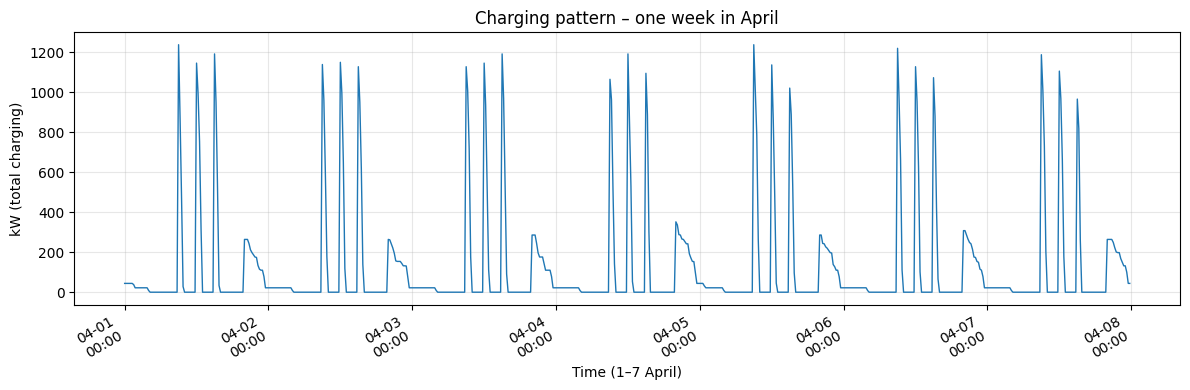

In [ ]:
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Same base series
x_all = [i2t[i] for i in T_idx]
p_total_all = [float(sum(P[v, i].X for v in V)) for i in T_idx]

# Define one week in April (here: 1–7 April)
year = x_all[0].year  # assumes all in same year
start = dt.datetime(year, 4, 1)
end   = dt.datetime(year, 4, 8)  # exclusive upper bound

x_week = []
p_week = []
for t, p in zip(x_all, p_total_all):
    if start <= t < end:
        x_week.append(t)
        p_week.append(p)

plt.figure(figsize=(12, 4))
plt.plot(x_week, p_week, lw=1, color="tab:blue")

plt.ylabel("kW (total charging)")
plt.xlabel("Time (1–7 April)")
plt.title("Charging pattern – one week in April")
plt.grid(True, alpha=0.3)

plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

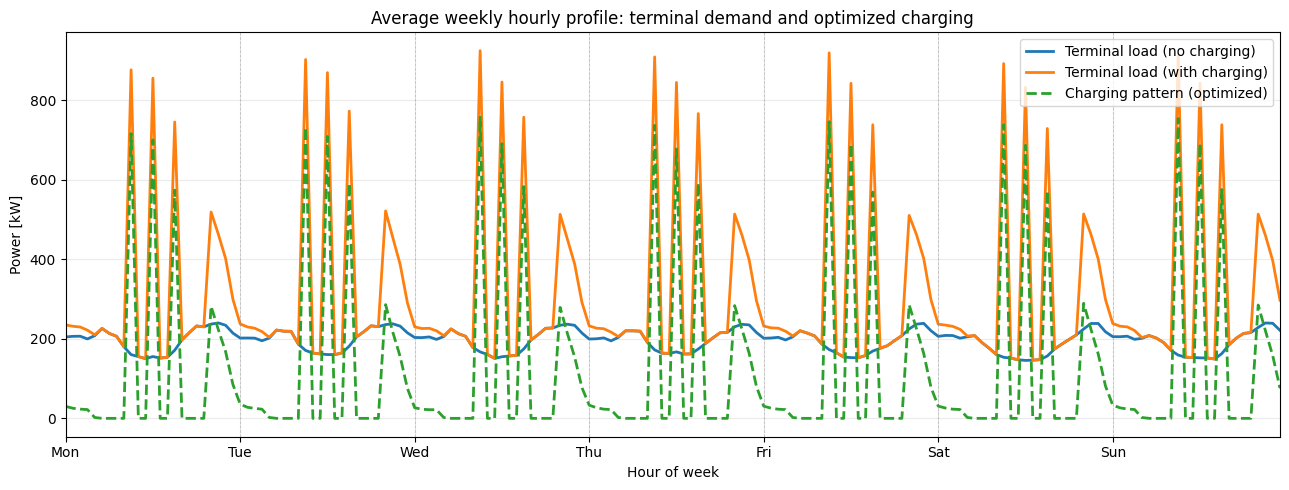

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace with your optimization-result dataframe variable if needed
# It must contain:
# - datetime
# - terminal_load_no_charging_kw
# - terminal_load_with_charging_kw
df_opt = df.copy()

# 1) Clean datetime
df_opt["datetime"] = pd.to_datetime(df_opt["datetime"], errors="coerce")
df_opt = df_opt.dropna(subset=["datetime"])

# 2) Derived series
df_opt["charging_kw"] = (
    df_opt["terminal_load_with_charging_kw"] - df_opt["terminal_load_no_charging_kw"]
).clip(lower=0)

# 3) Hour of week (0..167)
df_opt["hour_of_week"] = df_opt["datetime"].dt.dayofweek * 24 + df_opt["datetime"].dt.hour

# 4) Weekly average profiles
weekly = (
    df_opt.groupby("hour_of_week")[[
        "terminal_load_no_charging_kw",
        "terminal_load_with_charging_kw",
        "charging_kw"
    ]]
    .mean()
    .reindex(range(168))
    .reset_index()
)

# 5) Plot combined
plt.figure(figsize=(13, 5))

plt.plot(
    weekly["hour_of_week"],
    weekly["terminal_load_no_charging_kw"],
    label="Terminal load (no charging)",
    linewidth=2
)

plt.plot(
    weekly["hour_of_week"],
    weekly["terminal_load_with_charging_kw"],
    label="Terminal load (with charging)",
    linewidth=2
)

plt.plot(
    weekly["hour_of_week"],
    weekly["charging_kw"],
    label="Charging pattern (optimized)",
    linewidth=2,
    linestyle="--"
)

# Day separators
day_starts = [0, 24, 48, 72, 96, 120, 144]
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
for x in day_starts:
    plt.axvline(x=x, color="gray", linestyle="--", linewidth=0.6, alpha=0.4)

plt.xticks(day_starts, day_labels)
plt.xlim(0, 167)

# Zoom out a bit on y-axis by adding padding around data range
y_cols = ["terminal_load_no_charging_kw", "terminal_load_with_charging_kw", "charging_kw"]
y_min = weekly[y_cols].min().min()
y_max = weekly[y_cols].max().max()
y_pad = max(0.05 * (y_max - y_min), 10.0)
plt.ylim(y_min - y_pad, y_max + y_pad)

plt.xlabel("Hour of week")
plt.ylabel("Power [kW]")
plt.title("Average weekly hourly profile: terminal demand and optimized charging")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

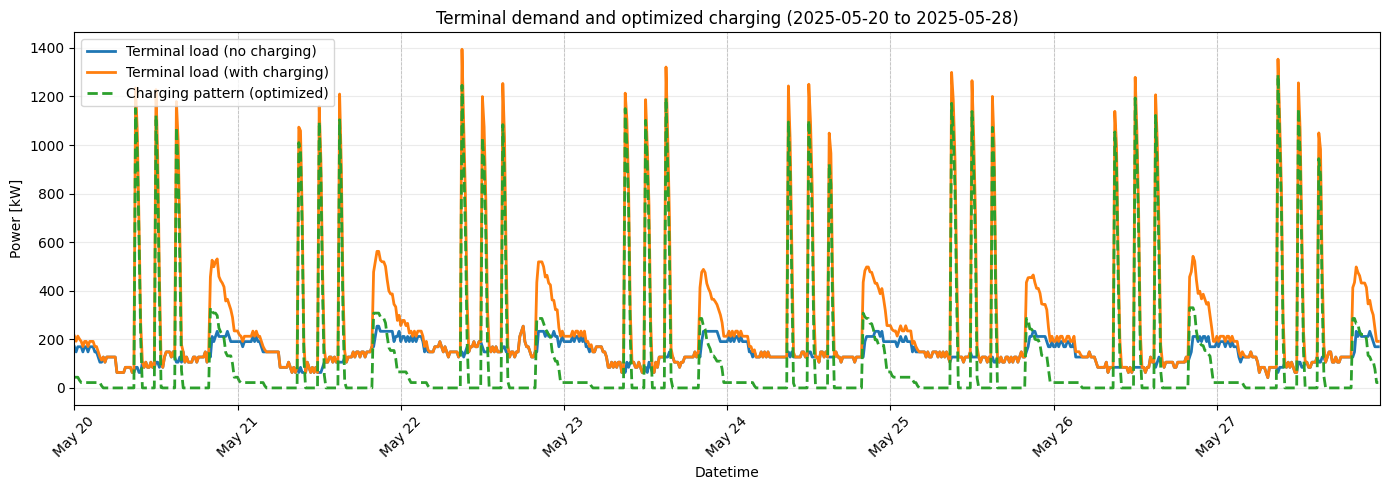

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace with your optimization-result dataframe variable if needed
# It must contain:
# - datetime
# - terminal_load_no_charging_kw
# - terminal_load_with_charging_kw
df_opt = df.copy()

# 1) Clean datetime
df_opt["datetime"] = pd.to_datetime(df_opt["datetime"], errors="coerce")
df_opt = df_opt.dropna(subset=["datetime"]).sort_values("datetime")

# 2) Derived series
df_opt["charging_kw"] = (
    df_opt["terminal_load_with_charging_kw"] - df_opt["terminal_load_no_charging_kw"]
).clip(lower=0)

# 3) Filter exact period (inclusive start, inclusive end date)
start = pd.Timestamp("2025-05-20 00:00:00")
end   = pd.Timestamp("2025-05-27 23:59:59")
period = df_opt[(df_opt["datetime"] >= start) & (df_opt["datetime"] <= end)].copy()

if period.empty:
    print("No data found in the selected period.")
else:
    plt.figure(figsize=(14, 5))

    plt.plot(
        period["datetime"],
        period["terminal_load_no_charging_kw"],
        label="Terminal load (no charging)",
        linewidth=2
    )

    plt.plot(
        period["datetime"],
        period["terminal_load_with_charging_kw"],
        label="Terminal load (with charging)",
        linewidth=2
    )

    plt.plot(
        period["datetime"],
        period["charging_kw"],
        label="Charging pattern (optimized)",
        linewidth=2,
        linestyle="--"
    )

    # Day separators + daily ticks
    day_starts = pd.date_range(start=start.normalize(), end=end.normalize(), freq="D")
    for x in day_starts:
        plt.axvline(x=x, color="gray", linestyle="--", linewidth=0.6, alpha=0.4)

    plt.xticks(day_starts, [d.strftime("%b %d") for d in day_starts], rotation=45)
    plt.xlim(start, end)
    plt.xlabel("Datetime")
    plt.ylabel("Power [kW]")
    plt.title("Terminal demand and optimized charging (2025-05-20 to 2025-05-28)")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
import os
import pandas as pd

# -----------------------------
# Build 15-min export table
# (cargoterminal power + vehicle charging only)
# -----------------------------
# Expected in notebook:
# - cargoterminal_power_demand: columns ["datetime", "power_kW"] (kW)
# - charging component:
#   - prefer df_opt["charging_kw"] if available (kW)
#   - else derive from df["terminal_load_with_charging_kw"] - df["terminal_load_no_charging_kw"]
#   - else fallback: sum Gurobi variables P[v,i].X

# cargo terminal (kW)
cargo = cargoterminal_power_demand.copy()
cargo["datetime"] = pd.to_datetime(cargo["datetime"], errors="coerce")
cargo["cargoterminal_power_kW"] = pd.to_numeric(cargo["power_kW"], errors="coerce")
cargo = (
    cargo[["datetime", "cargoterminal_power_kW"]]
    .dropna(subset=["datetime"])
    .drop_duplicates("datetime")
)

# Charging (kW)
charging = None
if "df_opt" in globals() and isinstance(df_opt, pd.DataFrame) and "charging_kw" in df_opt.columns:
    charging = df_opt[["datetime", "charging_kw"]].copy()
    charging["datetime"] = pd.to_datetime(charging["datetime"], errors="coerce")
    charging["vehicle_charging_kW"] = pd.to_numeric(charging["charging_kw"], errors="coerce")
    charging = charging[["datetime", "vehicle_charging_kW"]]
elif "df" in globals() and isinstance(df, pd.DataFrame):
    need_cols = {"terminal_load_with_charging_kw", "terminal_load_no_charging_kw"}
    if need_cols.issubset(df.columns):
        charging = df[["datetime", "terminal_load_with_charging_kw", "terminal_load_no_charging_kw"]].copy()
        charging["datetime"] = pd.to_datetime(charging["datetime"], errors="coerce")
        charging["vehicle_charging_kW"] = (
            pd.to_numeric(charging["terminal_load_with_charging_kw"], errors="coerce")
            - pd.to_numeric(charging["terminal_load_no_charging_kw"], errors="coerce")
        )
        charging = charging[["datetime", "vehicle_charging_kW"]]

if charging is None:
    # Final fallback: sum Gurobi variables P[v,i].X
    if "T_idx" not in globals() or "i2t" not in globals() or "V" not in globals() or "P" not in globals():
        raise RuntimeError(
            "Charging could not be derived: expected df_opt/df with charging columns, "
            "or Gurobi variables P,V,T_idx,i2t in scope."
        )

    rows = []
    for i in T_idx:
        t = i2t[i]
        total_charge_kw = 0.0
        for v in V:
            total_charge_kw += float(P[v, i].X)
        rows.append({"datetime": t, "vehicle_charging_kW": total_charge_kw})
    charging = pd.DataFrame(rows)
    charging["datetime"] = pd.to_datetime(charging["datetime"], errors="coerce")

charging = charging.dropna(subset=["datetime"]).drop_duplicates("datetime")

# 15-min datetime grid from min to max across available series (cargo + charging)
start_dt = min(cargo["datetime"].min(), charging["datetime"].min())
end_dt = max(cargo["datetime"].max(), charging["datetime"].max())
full_grid = pd.date_range(start=start_dt, end=end_dt, freq="15min")

out = pd.DataFrame({"datetime": full_grid})
out = out.merge(cargo, on="datetime", how="left")
out = out.merge(charging, on="datetime", how="left")

out[["cargoterminal_power_kW", "vehicle_charging_kW"]] = out[
    ["cargoterminal_power_kW", "vehicle_charging_kW"]
].fillna(0.0)

out["total_kW"] = out["cargoterminal_power_kW"] + out["vehicle_charging_kW"]

out = out.rename(
    columns={
        "cargoterminal_power_kW": "cargoterminal_power_demand_kW",
        "vehicle_charging_kW": "vehicle_charging_kW",
    }
)

# Export
os.makedirs("outputs/load_shifting/power_demands", exist_ok=True)
out_path = "outputs/load_shifting/power_demands/dumb_noshore_cargoterminal_vehicle_charging_15min.xlsx"
out.to_excel(out_path, index=False)

print("Wrote:", out_path)

Wrote: outputs/load_shifting/power_demands/dumb_noshore_cargoterminal_vehicle_charging_15min.xlsx


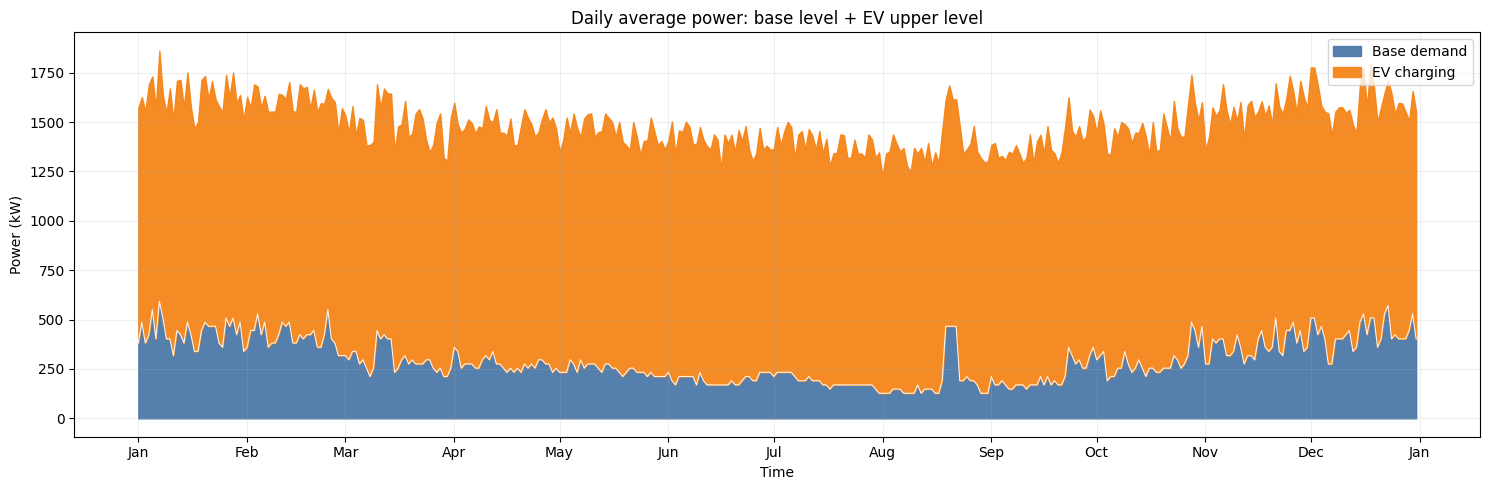

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

file_path = "outputs/load_shifting/power_demands/dumb_noshore_cargoterminal_vehicle_charging_15min.xlsx"

TIME_COL = "datetime"
BASE_COL = "cargoterminal_power_demand_kW"
EV_COL   = "vehicle_charging_kW"

df = pd.read_excel(file_path)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL)
df[BASE_COL] = pd.to_numeric(df[BASE_COL], errors="coerce").fillna(0).clip(lower=0)
df[EV_COL]   = pd.to_numeric(df[EV_COL], errors="coerce").fillna(0).clip(lower=0)

# Daily mean -> much cleaner
d = (df.set_index(TIME_COL)[[BASE_COL, EV_COL]]
       .resample("D").max()
       .reset_index())

total = d[BASE_COL] + d[EV_COL]

fig, ax = plt.subplots(figsize=(15,5))
ax.fill_between(d[TIME_COL], 0, d[BASE_COL], color="#4C78A8", alpha=0.95, label="Base demand")
ax.fill_between(d[TIME_COL], d[BASE_COL], total, color="#F58518", alpha=0.95, label="EV charging")
ax.plot(d[TIME_COL], d[BASE_COL], color="white", lw=0.8, alpha=0.9)

ax.set_ylabel("Power (kW)")
ax.set_xlabel("Time")
ax.set_title("Daily average power: base level + EV upper level")
ax.legend(loc="upper right")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

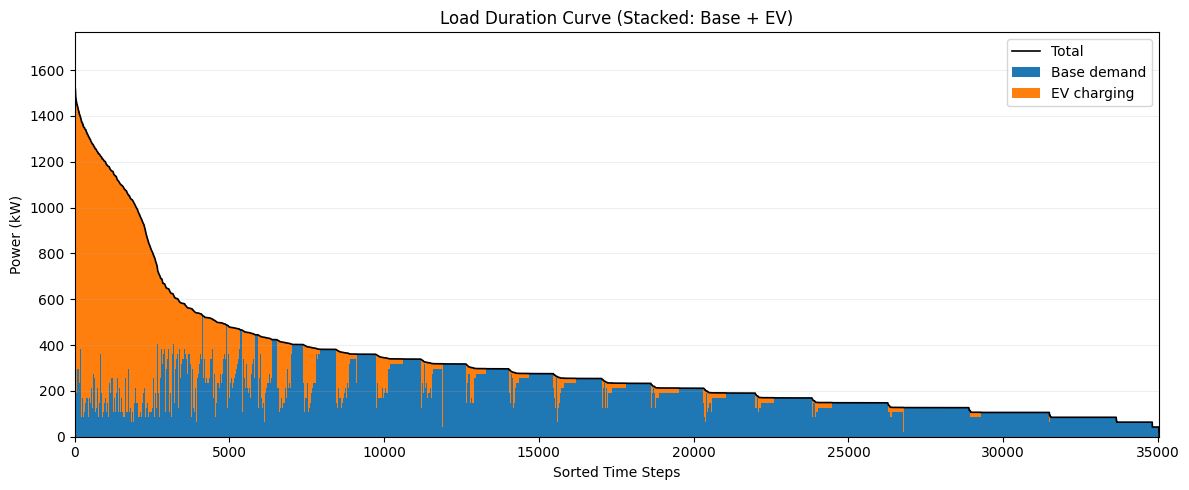

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Input
# ----------------------------
file_path = "outputs/load_shifting/power_demands/dumb_noshore_cargoterminal_vehicle_charging_15min.xlsx"
sheet_name = 0

TIME_COL = "datetime"
BASE_COL = "cargoterminal_power_demand_kW"
EV_COL   = "vehicle_charging_kW"

# ----------------------------
# Load and clean
# ----------------------------
df = pd.read_excel(file_path, sheet_name=sheet_name)

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.dropna(subset=[TIME_COL])

df[BASE_COL] = pd.to_numeric(df[BASE_COL], errors="coerce").fillna(0).clip(lower=0)
df[EV_COL]   = pd.to_numeric(df[EV_COL],   errors="coerce").fillna(0).clip(lower=0)

# ----------------------------
# Build load duration data
# ----------------------------
tmp = df[[BASE_COL, EV_COL]].copy()
tmp["total"] = tmp[BASE_COL] + tmp[EV_COL]

# Sort descending by total load (duration curve)
tmp = tmp.sort_values("total", ascending=False).reset_index(drop=True)

# x = sorted time-step index
x = np.arange(len(tmp))

base_sorted = tmp[BASE_COL].values
ev_sorted   = tmp[EV_COL].values
total_sorted = tmp["total"].values

# ----------------------------
# Plot (stacked, like your example)
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

# Stacked bars create the "striped" style from your screenshot
ax.bar(x, base_sorted, width=1.0, color="#1f77b4", label="Base demand", linewidth=0)
ax.bar(x, ev_sorted,   width=1.0, bottom=base_sorted, color="#ff7f0e", label="EV charging", linewidth=0)

# Top envelope line
ax.plot(x, total_sorted, color="black", linewidth=1.2, label="Total")

ax.set_title("Load Duration Curve (Stacked: Base + EV)")
ax.set_xlabel("Sorted Time Steps")
ax.set_ylabel("Power (kW)")
ax.set_xlim(0, len(x)-1)
ax.set_ylim(0, total_sorted.max() * 1.05)
ax.grid(alpha=0.2, axis="y")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()